# Issue #1: Define Congestion Metric and Forecasting Target

This notebook defines a reproducible congestion target for forecasting, documents cleaning rules, and creates labeled congestion levels for downstream dashboards and modeling.

## 1) Setup

In [7]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

## 2) Data Loading

The notebook looks for `svc_summary_data.csv` in standard project locations and fails with a clear debug message if the file is not found.

In [8]:
file_name = "svc_summary_data.csv"
data_path = Path("../data/raw") / file_name

df = pd.read_csv(data_path)
print(f"Loaded file: {data_path}")
print(f"Raw dataset shape: {df.shape}")

Loaded file: ../data/raw/svc_summary_data.csv
Raw dataset shape: (44470, 21)


## 3) Data Understanding

### Key fields used in this analysis

- `avg_daily_vol`: Average daily vehicle volume at a location; this is used as the baseline congestion signal.
- `avg_speed`: Average observed speed across records for the location/time window.
- `avg_85th_percentile_speed`: Speed below which 85% of observed vehicles travel.
- `avg_95th_percentile_speed`: Speed below which 95% of observed vehicles travel.
- `avg_heavy_pct`: Percentage of heavy vehicles in the traffic mix.

In [9]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

key_numeric_fields = [
    "avg_daily_vol",
    "avg_speed",
    "avg_85th_percentile_speed",
    "avg_95th_percentile_speed",
    "avg_heavy_pct",
]

available_key_fields = [c for c in key_numeric_fields if c in df.columns]
missing_key_fields = [c for c in key_numeric_fields if c not in df.columns]

if missing_key_fields:
    print("\nWarning: Missing expected key fields:", missing_key_fields)

print("\nDescriptive statistics for key numeric fields:")
print(df[available_key_fields].describe().T)

Dataset shape: (44470, 21)

Columns:
['_id', 'count_id', 'count_type', 'count_date_start', 'count_date_end', 'count_duration', 'location_name', 'longitude', 'latitude', 'centreline_id', 'avg_daily_vol', 'avg_weekday_daily_vol', 'avg_weekend_daily_vol', 'avg_wkdy_am_peak_start', 'avg_wkdy_am_peak_vol', 'avg_wkdy_pm_peak_start', 'avg_wkdy_pm_peak_vol', 'avg_speed', 'avg_85th_percentile_speed', 'avg_95th_percentile_speed', 'avg_heavy_pct']

Dtypes:
_id                            int64
count_id                       int64
count_type                       str
count_date_start                 str
count_date_end                   str
count_duration                 int64
location_name                    str
longitude                    float64
latitude                     float64
centreline_id                  int64
avg_daily_vol                float64
avg_weekday_daily_vol        float64
avg_weekend_daily_vol        float64
avg_wkdy_am_peak_start           str
avg_wkdy_am_peak_vol         flo

## 4) Target Definition

### Final choice: `congestion_target = avg_daily_vol`

We define congestion as **traffic demand pressure**, using average daily volume as a direct, interpretable proxy. Higher volume generally implies greater demand on roadway capacity and thus higher congestion risk.

`avg_daily_vol` is selected as the forecasting target because:

- it is numeric and directly forecastable,
- it is available at scale in this dataset,
- it aligns with planning and operations use cases where flow demand is a primary KPI.

In [10]:
df["congestion_target"] = df["avg_daily_vol"]

target_missing = df["congestion_target"].isna().sum()
target_zero = (df["congestion_target"] == 0).sum()
target_total = len(df)

print("Target diagnostics (before cleaning):")
print(f"- Total rows: {target_total:,}")
print(f"- Missing congestion_target: {target_missing:,} ({target_missing/target_total:.2%})")
print(f"- Zero congestion_target: {target_zero:,} ({target_zero/target_total:.2%})")

Target diagnostics (before cleaning):
- Total rows: 44,470
- Missing congestion_target: 0 (0.00%)
- Zero congestion_target: 0 (0.00%)


## 5) Cleaning Rules

Cleaning policy for modeling dataset:

- Drop rows where `congestion_target` is missing (target cannot be trained/forecast when absent).
- Treat `avg_daily_vol == 0` as invalid volume count and drop those rows.
- For non-target analysis fields (`avg_speed`, percentile speeds, `avg_heavy_pct`), impute missing values with the column median to retain usable target rows while keeping the strategy simple and robust.

In [11]:
model_df = df.copy()
initial_rows = len(model_df)

rows_missing_target = model_df["congestion_target"].isna().sum()
model_df = model_df.dropna(subset=["congestion_target"]).copy()

after_missing_drop_rows = len(model_df)
rows_zero_target = (model_df["congestion_target"] == 0).sum()
model_df = model_df[model_df["congestion_target"] != 0].copy()

impute_fields = ["avg_speed", "avg_85th_percentile_speed", "avg_95th_percentile_speed", "avg_heavy_pct"]
imputation_report = {}

for col in impute_fields:
    if col in model_df.columns:
        missing_count = model_df[col].isna().sum()
        median_value = model_df[col].median()
        if missing_count > 0:
            model_df[col] = model_df[col].fillna(median_value)
        imputation_report[col] = {
            "missing_before": int(missing_count),
            "median_used": float(median_value) if pd.notna(median_value) else np.nan,
        }

final_rows = len(model_df)
rows_removed_total = initial_rows - final_rows

print("Cleaning summary:")
print(f"- Initial rows: {initial_rows:,}")
print(f"- Removed for missing target: {rows_missing_target:,}")
print(f"- Removed for zero target: {rows_zero_target:,}")
print(f"- Total rows removed: {rows_removed_total:,}")
print(f"- Final rows: {final_rows:,}")

print("\nImputation summary (non-target fields):")
for col, stats in imputation_report.items():
    print(f"- {col}: filled {stats['missing_before']:,} missing values with median={stats['median_used']:.3f}")

print("\nTarget summary after cleaning:")
print(model_df["congestion_target"].describe())

Cleaning summary:
- Initial rows: 44,470
- Removed for missing target: 0
- Removed for zero target: 0
- Total rows removed: 0
- Final rows: 44,470

Imputation summary (non-target fields):
- avg_speed: filled 28,361 missing values with median=36.800
- avg_85th_percentile_speed: filled 28,361 missing values with median=44.900
- avg_95th_percentile_speed: filled 28,361 missing values with median=50.000
- avg_heavy_pct: filled 44,103 missing values with median=0.069

Target summary after cleaning:
count     44470.000000
mean      10489.242770
std        9890.232381
min           1.000000
25%        1922.175000
50%        8903.350000
75%       15729.225000
max      117916.000000
Name: congestion_target, dtype: float64


## 6) Congestion Level Labels

Create 4 dashboard-friendly levels (`Low`, `Medium`, `High`, `Severe`) from `congestion_target`.

- Primary method: `pd.qcut(..., q=4, duplicates="drop")`
- Fallback: percentile-based `pd.cut` bins adjusted to ensure strictly increasing bin edges, still yielding 4 levels.

In [12]:
level_labels = ["Low", "Medium", "High", "Severe"]

target_series = model_df["congestion_target"].astype("float64")
qcut_method_used = None

try:
    qcut_bins = pd.qcut(target_series, q=4, duplicates="drop")
    n_bins = qcut_bins.cat.categories.size

    if n_bins == 4:
        model_df["congestion_level"] = qcut_bins.cat.rename_categories(level_labels)
        qcut_method_used = 'qcut (4 bins)'
    else:
        raise ValueError(f"qcut returned {n_bins} bins instead of 4")
except Exception as exc:
    percentile_edges = np.percentile(target_series, [0, 25, 50, 75, 100]).astype(float)

    # Ensure strictly increasing edges for pd.cut
    for i in range(1, len(percentile_edges)):
        if percentile_edges[i] <= percentile_edges[i - 1]:
            percentile_edges[i] = percentile_edges[i - 1] + 1e-6

    cut_bins = [float(x) for x in percentile_edges.tolist()]

    model_df["congestion_level"] = pd.cut(
        target_series,
        bins=cut_bins,
        labels=level_labels,
        include_lowest=True,
        right=True,
    )
    qcut_method_used = f"percentile fallback ({exc})"

if model_df["congestion_level"].isna().any():
    # Final guardrail to guarantee all rows receive one of 4 labels
    model_df["congestion_level"] = pd.qcut(
        target_series.rank(method="first"),
        q=4,
        labels=level_labels,
    )
    qcut_method_used += " + rank-based guardrail"

model_df["congestion_level"] = pd.Categorical(model_df["congestion_level"], categories=level_labels, ordered=True)

print("Congestion level method:", qcut_method_used)
print("\nDistribution by congestion_level:")
print(model_df["congestion_level"].value_counts().reindex(level_labels))



Congestion level method: qcut (4 bins)

Distribution by congestion_level:
congestion_level
Low       11118
Medium    11117
High      11117
Severe    11118
Name: count, dtype: int64


## 7) Visual Checks

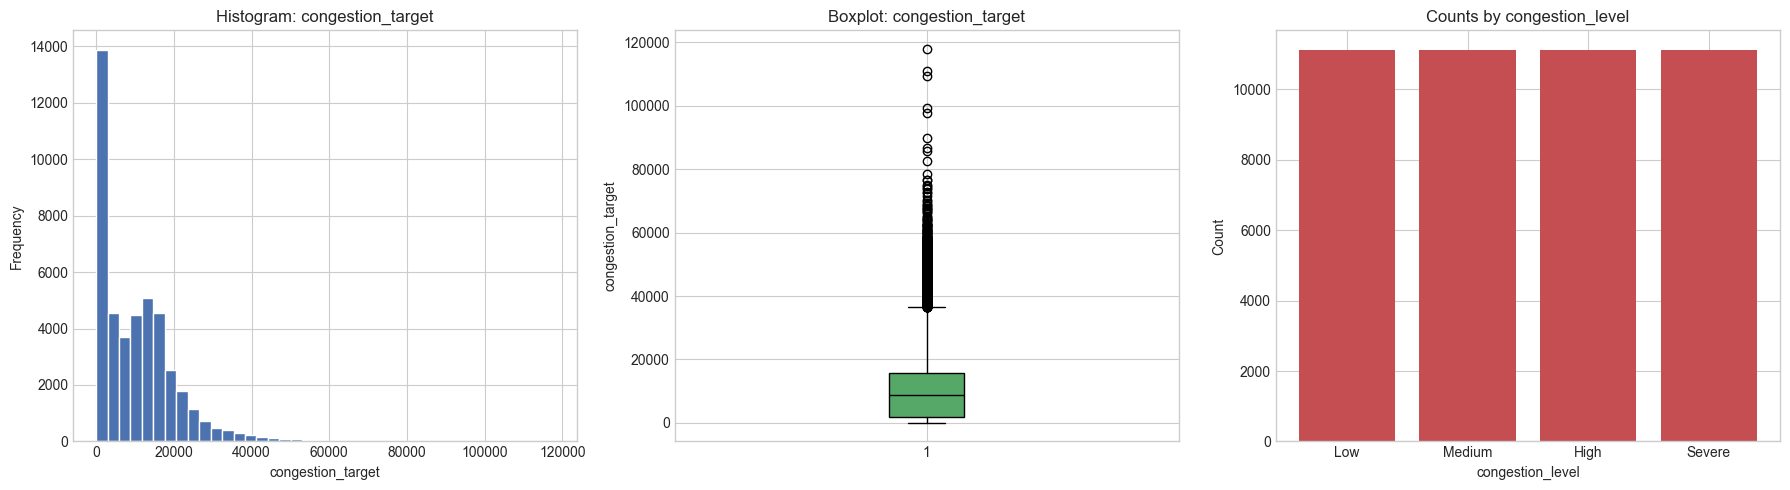

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(model_df["congestion_target"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Histogram: congestion_target")
axes[0].set_xlabel("congestion_target")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(model_df["congestion_target"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#55A868"), medianprops=dict(color="black"))
axes[1].set_title("Boxplot: congestion_target")
axes[1].set_ylabel("congestion_target")

level_counts = model_df["congestion_level"].value_counts().reindex(level_labels)
axes[2].bar(level_counts.index.astype(str), level_counts.values, color="#C44E52")
axes[2].set_title("Counts by congestion_level")
axes[2].set_xlabel("congestion_level")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 8) Team Output Dataset

Save a compact cleaned dataset for modeling and dashboarding to `data/processed/svc_summary_clean.csv`.

In [14]:
raw_data_dir = data_path.parent
project_data_dir = raw_data_dir.parent
processed_dir = project_data_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

relevant_columns = [
    "count_id",
    "location_name",
    "count_date_start",
    "count_date_end",
    "avg_daily_vol",
    "avg_speed",
    "avg_85th_percentile_speed",
    "avg_95th_percentile_speed",
    "avg_heavy_pct",
    "congestion_target",
    "congestion_level",
]

existing_relevant_columns = [c for c in relevant_columns if c in model_df.columns]
svc_summary_clean = model_df[existing_relevant_columns].copy()

output_path = processed_dir / "svc_summary_clean.csv"
svc_summary_clean.to_csv(output_path, index=False)

print(f"Saved cleaned dataset to: {output_path}")
print(f"Output shape: {svc_summary_clean.shape}")
print(f"Columns saved: {existing_relevant_columns}")

Saved cleaned dataset to: ../data/processed/svc_summary_clean.csv
Output shape: (44470, 11)
Columns saved: ['count_id', 'location_name', 'count_date_start', 'count_date_end', 'avg_daily_vol', 'avg_speed', 'avg_85th_percentile_speed', 'avg_95th_percentile_speed', 'avg_heavy_pct', 'congestion_target', 'congestion_level']


## 9) Decision Summary

In [15]:
from IPython.display import Markdown, display

decision_md = f"""
### Decision Summary

- **Final congestion target definition:** `congestion_target = avg_daily_vol`.
- **Rows dropped:** {rows_missing_target:,} rows with missing target and {rows_zero_target:,} rows with zero target (treated as invalid counts).
- **Final number of records:** {final_rows:,}.
- **Congestion levels:** 4 ordered labels (`Low`, `Medium`, `High`, `Severe`) based on quartile-style binning of `congestion_target`.
  Primary method is `pd.qcut(q=4, duplicates='drop')`; fallback uses adjusted percentile bins to preserve 4 levels.
"""

display(Markdown(decision_md))


### Decision Summary

- **Final congestion target definition:** `congestion_target = avg_daily_vol`.
- **Rows dropped:** 0 rows with missing target and 0 rows with zero target (treated as invalid counts).
- **Final number of records:** 44,470.
- **Congestion levels:** 4 ordered labels (`Low`, `Medium`, `High`, `Severe`) based on quartile-style binning of `congestion_target`.
  Primary method is `pd.qcut(q=4, duplicates='drop')`; fallback uses adjusted percentile bins to preserve 4 levels.
